In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import re

ns_book = pd.read_csv(r'C:\data\ns_book7.csv', encoding='utf-8', low_memory=False)
ns_book.head(10)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19
5,6,처음 읽는 음식의 세계사,"미야자키 마사카츠 지음, 한세희 옮김",탐나는책,2021,9791189550370,NaN,NaN,NaN,NaN,1,0,2021-03-19
6,7,아르센 벵거 자서전 My Life in Red and White,"아르센 벵거 지음, 이성모 옮김",한즈미디어(한스미디어),2021,9791160075793,NaN,NaN,NaN,NaN,1,0,2021-03-19
7,8,쓰고 달콤한 직업,천운영 지음,마음산책,2021,9788960906679,NaN,NaN,NaN,NaN,1,0,2021-03-19
8,9,일잘러의 노션 100% 활용법,제레미 강 지음,위키북스,2021,9791158392512,NaN,NaN,NaN,NaN,1,0,2021-03-19
9,10,타이난 골목 노포 산책,"천구이팡 지음, 심혜경 외 옮김",페이퍼스토리,2021,9788998690557,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [4]:
s = (ns_book['권'].fillna('1').astype('string').str.strip()
     .str.replace('下', '하', regex=False)
     .str.replace('上', '상', regex=False)
     .str.replace('하나', '1', regex=False))
ns_book['권'] = s

In [5]:
valid = ns_book['등록일자'].astype('string').str.strip().str.fullmatch(r'\d{4}-\d{2}-\d{2}')
ns_book = ns_book[valid]

#등록일자 타임스탬프, 가용일수 만들기
ns_book['등록일자_dt'] = pd.to_datetime(ns_book['등록일자'], format='%Y-%m-%d', errors='coerce')
기준연월 = pd.Timestamp('2022-12-31')
가용일수 = (기준연월 - ns_book['등록일자_dt']).dt.days
ns_book['가용일수'] = 가용일수
popular_book_loan = ((ns_book['대출건수'] / ns_book['가용일수']) * 365)
ns_book['일수 대비 대출건수'] = popular_book_loan

popular_book_by_loan = ns_book.groupby(['도서명', '권'], dropna=False)['일수 대비 대출건수'].mean()
popular_book_by_loan.sort_values(ascending=False).head(20)

ns_book
#가용일수 초과치 제거
# 가용일수데이터 = ns_book.loc[ns_book[가용일수].lt(10000), '가용일수']
# 가용일수데이터

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,등록일자_dt,가용일수,일수 대비 대출건수
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,1,NaN,1,0,2021-03-19,2021-03-19,652,0.0
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,1,NaN,1,0,2021-03-19,2021-03-19,652,0.0
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,1,NaN,1,0,2021-03-19,2021-03-19,652,0.0
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,1,NaN,1,0,2021-03-19,2021-03-19,652,0.0
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,1,NaN,1,0,2021-03-19,2021-03-19,652,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376765,401674,소설의 사회사 비교론,조동일 지음,지식산업사,2001,9788942340262,9788942300365,NaN,3,809.3,1,0,1970-01-01,1970-01-01,19357,0.0
376766,401677,큰오빠,박정근 지음,우리문학사,1998,9788974231323,9788974231309,NaN,2,813.6,2,0,1970-01-01,1970-01-01,19357,0.0
376767,401678,韓國現代詩大系,채만묵 編著,한국문화사,1996,9788977352971,9788977352988,NaN,3,811.608,1,0,1970-01-01,1970-01-01,19357,0.0
376768,401679,뉴 웨이브,제임스 모나코 지음,한나래,1996,9788985367448,9788985367424,NaN,2,688.04,1,0,1970-01-01,1970-01-01,19357,0.0


In [9]:
#일수대비대출건수 데이터 정리 top20

df_array = ns_book.loc[:, ['도서명', '일수 대비 대출건수']]
df_array.set_index('도서명', inplace=True)
loan_per_day_data = df_array['일수 대비 대출건수'].sort_values(ascending=False)

loan_per_day_data = loan_per_day_data.head(20)



TypeError: Axis.set_ticks() missing 1 required positional argument: 'ticks'

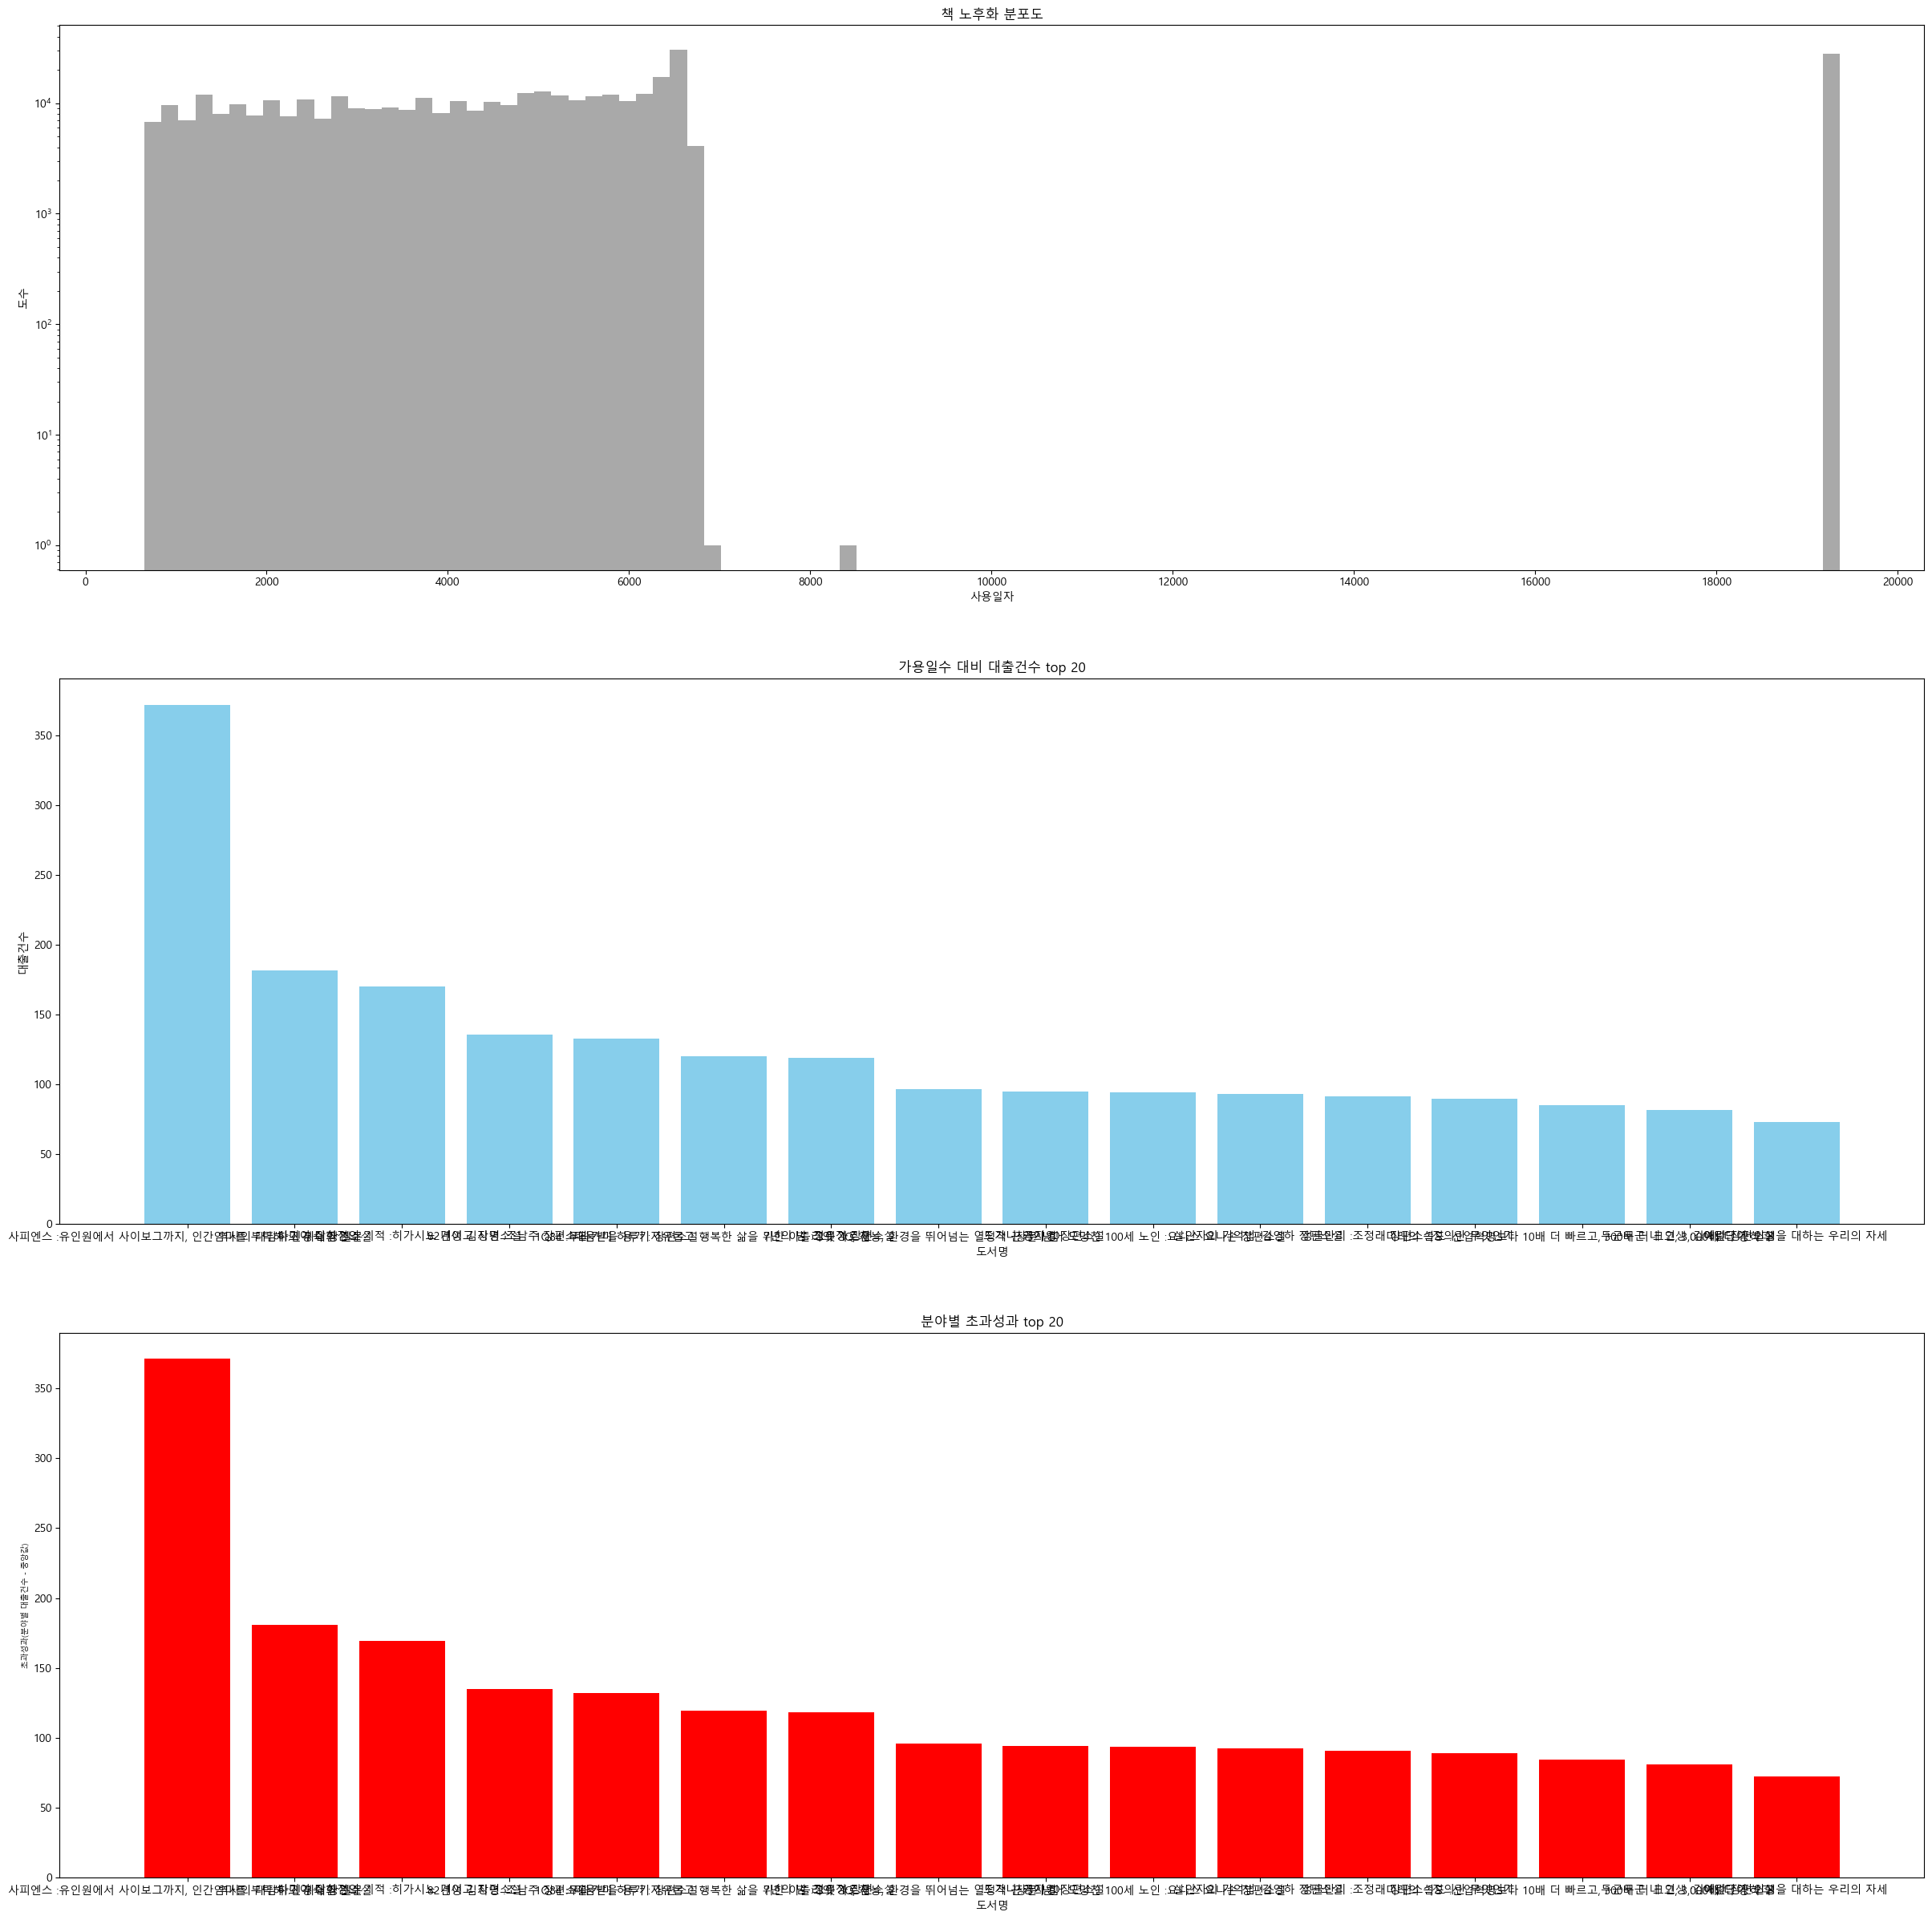

In [16]:
#분야별 초과성과 데이터 만들기
import numpy as np

# 주제분류번호 전처리 : NaN, 빈값 -> -1, 나머지 첫번쨰 자리만
def cleansing_num(x):
    if pd.isna(x):
        return '-1'
    if str(x).strip() == '':
        return '-1'
    if str(x).__contains__(r'\D'):
        return '-1'
    else:
        return str(x)[0]
ns_book['주제분류번호'] = ns_book['주제분류번호'].apply(cleansing_num)
ns_book['주제분류별중앙값'] = ns_book.groupby('주제분류번호', dropna=False)['일수 대비 대출건수'].transform('median')
초과성과 = ns_book['일수 대비 대출건수'] - ns_book['주제분류별중앙값']
ns_book['초과성과'] = 초과성과

df_array = ns_book.loc[:, ['도서명', '초과성과']]
초과성과데이터프레임 = df_array.set_index('도서명')
초과성과데이터 = 초과성과데이터프레임['초과성과'].sort_values(ascending=False)
exd_result = 초과성과데이터.head(20)



#서브플롯 만들기 (1) 노후화 책 분포도 히스토그램. (2) 가용일수 대비 대출건수 top 20 (3) 같은 분야 대비 초과성과 막대그래프
plt.rcParams['font.family'] = 'malgun gothic'

fig, axs = plt.subplots(3, figsize=(30, 30))
axs[0].hist(ns_book['가용일수'], bins=100, color='darkgrey')
axs[0].set_title('책 노후화 분포도')
axs[0].set_xlabel('사용일자')
axs[0].set_ylabel('도수')
axs[0].set_yscale('log')
axs[0].set_xticks(range(0, 21000, 2000))
#히스토그램에서 annotate하는 방법?

axs[1].bar(loan_per_day_data.index, loan_per_day_data.values, color='skyblue')
axs[1].set_title('가용일수 대비 대출건수 top 20')
axs[1].set_xlabel('도서명')
axs[1].set_ylabel('대출건수')

axs[2].bar(exd_result.index, exd_result.values, color = 'red')
axs[2].set_title('분야별 초과성과 top 20')
axs[2].set_xlabel('도서명', fontsize=10)
axs[2].set_ylabel('초과성과(분야별 대출건수 - 중앙값)', fontsize=7)
axs[2].set_xticks(fontsize=6)








